## AGRUPAR GRAFICAS FIJANDO Nº DE COLUMNAS DE LA MATRIZ DE GRAFICAS

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import style

import seaborn as sns

%matplotlib inline

In [ ]:
import warnings
warnings.filterwarnings("ignore")

style.use('ggplot') or plt.style.use('ggplot')

## Carga datos

In [ ]:
ruta = '/content/drive/MyDrive/ESPECIALISTA IA/house_price (1).csv'

df_house = pd.read_csv(ruta)

df_house.head()

In [ ]:
df_house.info()

In [ ]:
df_house.drop(columns='id', inplace=True)

df_house.drop_duplicates(inplace=True)

## Separamos variables:

In [ ]:
var_numericas = df_house.select_dtypes(exclude=['object']).columns.to_list()
var_numericas

### Ejemplo sencillo (gráficas máximo detalle, apiladas verticalmente)

In [ ]:
colores = sns.color_palette("husl", len(var_numericas))


In [ ]:
# creacion graficas
fig, axes = plt.subplots(len(var_numericas), 1, figsize=(10, 5*len(var_numericas)), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})

ax = axes.ravel()

# dibujamos las graficas
for idx,variable in enumerate(var_numericas):

    # utilizar el método de dibujo que nos interese en cada momento
    # sustituir nombre dataframe y parámetros según método de dibujo

    sns.histplot(data=df_house, x=variable, bins=30, ax=ax[idx], color=colores[idx])

    ax[idx].set_title(f'HISTOGRAMA {variable}')
    ax[idx].set_xlabel(f'Valores atributo {variable}')
    ax[idx].set_ylabel("Frequencia")



### Matriz de gráficas con HISTOGRAMA y BOXPLOT variable por fila

In [ ]:
# valores colormap
TABLEAU_CMP = ('tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', \
               'tab:gray','tab:olive', 'tab:cyan')

In [ ]:
# creamos la grafica
fig, axes = plt.subplots(len(var_numericas), 2, figsize=(20, 5 * len(var_numericas)), gridspec_kw={'hspace': 0.4, 'wspace': 0.1})
ax = axes.ravel()

# graficas distribucion y boxplot de cada atributo
for idx, atributo in enumerate(var_numericas):

    # distribucion (histograma)
    sns.histplot(data=df_house, x=atributo, bins=30, ax=ax[2 * idx], color=TABLEAU_CMP[idx % len(TABLEAU_CMP)], alpha=0.15)

    # titulo, etiquetas histograma
    ax[2 * idx].set_title(f'HISTOGRAMA {atributo}')
    ax[2 * idx].set_xlabel(f'Valores {atributo}')
    ax[2 * idx].set_ylabel("Frequencia")

    # boxplot
    sns.boxplot(x=atributo, data=df_house, ax=ax[2 * idx + 1], color=TABLEAU_CMP[idx % len(TABLEAU_CMP)])

    # titulo, etiquetas boxplot
    ax[2 * idx + 1].set_title(f'BOXPLOT {atributo}')
    ax[2 * idx + 1].set_xlabel(f'Valores {atributo}')


# guardamos grafica:
fig.savefig('numericas')

## GRÁFICAS APILADAS

Utilizaremos dataset "titanic":

In [ ]:
ruta = '/content/drive/MyDrive/ESPECIALISTA IA/titanic.csv'

df = pd.read_csv(ruta)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Name                     887 non-null    object 
 3   Sex                      887 non-null    object 
 4   Age                      887 non-null    float64
 5   Siblings/Spouses Aboard  887 non-null    int64  
 6   Parents/Children Aboard  887 non-null    int64  
 7   Fare                     887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB


#### MULTIPLE: "DODGE"

<AxesSubplot:xlabel='Pclass', ylabel='Count'>

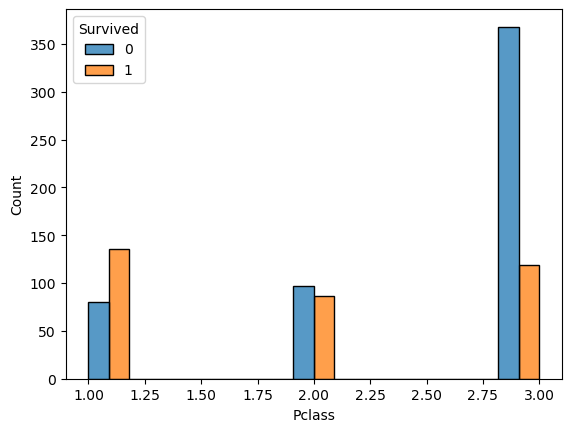

In [ ]:
sns.histplot(data=df, x="Pclass", hue="Survived", multiple="dodge")

#### MULTIPLE: "STACK"

<AxesSubplot:xlabel='Pclass', ylabel='Count'>

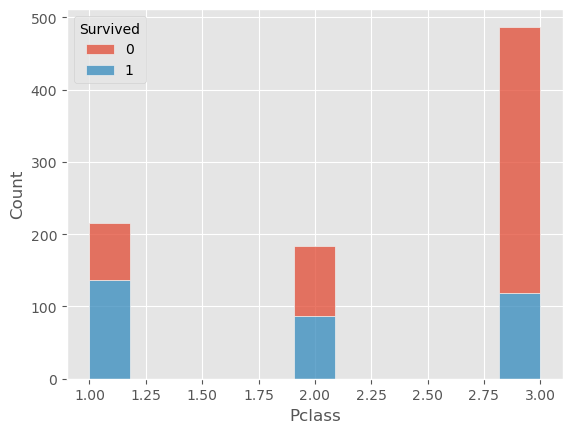

In [ ]:
sns.histplot(data=df, x="Pclass", hue="Survived", multiple="stack")

#### MULTIPLE: "FILL"

<AxesSubplot:xlabel='Pclass', ylabel='Count'>

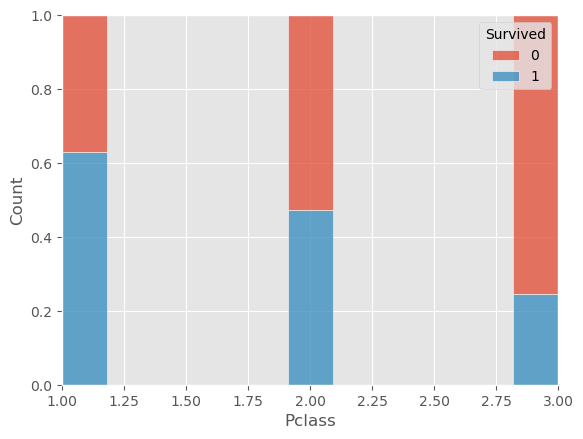

In [ ]:
sns.histplot(data=df, x="Pclass", hue="Survived", multiple="fill")